# Experiment 04 — maximize fraud F1

Experiment 03 tuned the cutoff with **F2**, which favors recall. That gave about **87% recall / 83% precision** (fraud F1 ≈ 0.85) at `t=0.25`. Pushing recall further wrecked precision.

This notebook optimizes **class-1 F1** (fraud) on the train set, then locks the cutoff for test. F1 only stays high if precision stays high too.

**What we do**
1. Keep the original imbalanced split and test set.
2. Reuse KNN and RF stacking scores.
3. Retrain the decision tree with the same hyperparameters plus `class_weight="balanced"` (the tree was trained without it).
4. Fit the meta Random Forest with the experiment 03 architecture and `class_weight=None` so it does not flood false positives.
5. Choose the cutoff that maximizes **train fraud F1**. Ties go to higher precision, then higher threshold.

**What we skip**
- 95% recall targets and `class_weight="balanced"` on the meta-learner (both dump precision).
- Random 50/50 undersampling, fraud IQR dropping, and SMOTE.


In [1]:
import time
from itertools import combinations
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


In [2]:
DATA_DIR = Path("../_data")
MODEL_DIR = Path("../_models")
META_FEATURES = ["pred_dt", "pred_knn", "pred_rf"]
REQUIRED_THRESHOLDS = [0.3, 0.5, 0.7]
METRIC_COLS = ["setting", "threshold", "precision", "recall", "f1", "tp", "fn", "fp"]

DT_SEARCH_PATH = MODEL_DIR / "dt_random_search_result_2026_08_13_02_00_27.pkl"
STACK_SEARCH_PATH = MODEL_DIR / "rf_stacking_search_result_2026_08_20_17_30_45.pkl"


In [3]:
def predict_at_threshold(proba, threshold):
    return (proba >= threshold).astype(int)


def metrics_at_threshold(y_true, proba, threshold):
    y_true = np.asarray(y_true).ravel()
    y_pred = predict_at_threshold(proba, threshold)
    return {
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "tp": int(((y_true == 1) & (y_pred == 1)).sum()),
        "fn": int(((y_true == 1) & (y_pred == 0)).sum()),
        "fp": int(((y_true == 0) & (y_pred == 1)).sum()),
        "tn": int(((y_true == 0) & (y_pred == 0)).sum()),
    }


def threshold_sweep(y_true, proba, thresholds):
    return pd.DataFrame(
        [metrics_at_threshold(y_true, proba, t) for t in thresholds]
    ).sort_values("threshold")


def pick_threshold_for_f1(train_df):
    row = train_df.sort_values(
        ["f1", "precision", "threshold"],
        ascending=[False, False, False],
    ).iloc[0]
    return float(row["threshold"]), row, "max train fraud F1"


def plot_report_and_cm(y_true, y_pred, title):
    class_labels = ["Legitimate", "Fraud"]
    report_dict = classification_report(
        y_true, y_pred, target_names=class_labels, output_dict=True, zero_division=0
    )
    accuracy = report_dict.pop("accuracy")
    report_df = pd.DataFrame(report_dict).T
    report_df["accuracy"] = accuracy
    report_metrics = report_df[["precision", "recall", "f1-score", "support", "accuracy"]]
    cm = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(report_metrics, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, ax=axes[0])
    axes[0].set_title(f"{title} Classification Report")
    axes[0].set_ylabel("")
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_labels, yticklabels=class_labels, ax=axes[1],
    )
    axes[1].set_title(f"{title} Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    plt.tight_layout()
    plt.show()


def show_metrics(df, cols=None):
    view = df if cols is None else df[cols]
    print(view.round({
        "threshold": 2, "precision": 4, "recall": 4, "f1": 4, "f2": 4, "accuracy": 6,
    }).to_string(index=False))


In [4]:
df = pd.read_csv(DATA_DIR / "creditcard.csv", index_col=0)
X = df.drop(columns=["Class"])
y = df["Class"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_train = y_train.squeeze()
y_test = y_test.squeeze()

old_stack_train = pd.read_csv(DATA_DIR / "stacking_train_data.csv")
old_stack_test = pd.read_csv(DATA_DIR / "stacking_test_data.csv")
assert np.array_equal(old_stack_train["Class"].to_numpy(), y_train.to_numpy())
assert np.array_equal(old_stack_test["Class"].to_numpy(), y_test.to_numpy())

old_stacker = joblib.load(STACK_SEARCH_PATH)
print("Train:", X_train.shape, "fraud:", int(y_train.sum()))
print("Test:", X_test.shape, "fraud:", int(y_test.sum()))
print("Old stacker params:", old_stacker.best_params_)


Train: (227845, 30) fraud: 394
Test: (56962, 30) fraud: 98
Old stacker params: {'n_estimators': 300, 'min_samples_split': 25, 'min_samples_leaf': 46, 'max_features': 1, 'max_depth': 20, 'criterion': 'entropy', 'class_weight': None, 'bootstrap': True}


## A. Experiment 03 stacker, cutoff chosen for fraud F1

Same saved meta-model. Experiment 03 used train **F2** (`t=0.25`). Here we pick the cutoff by train **F1** and keep `0.3 / 0.5 / 0.7` for the assignment.


In [5]:
candidate_thresholds = np.unique(np.round(np.concatenate([
    np.linspace(0.05, 0.95, 91),
    REQUIRED_THRESHOLDS,
    [0.25],
]), 4))

old_proba_train = old_stacker.predict_proba(old_stack_train[META_FEATURES])[:, 1]
old_proba_test = old_stacker.predict_proba(old_stack_test[META_FEATURES])[:, 1]
old_train_sweep = threshold_sweep(y_train, old_proba_train, candidate_thresholds)
old_t_f1, old_train_row, old_rule = pick_threshold_for_f1(old_train_sweep)

old_exp03 = metrics_at_threshold(y_test, old_proba_test, 0.25)
old_f1_op = metrics_at_threshold(y_test, old_proba_test, old_t_f1)
old_test_sweep = threshold_sweep(y_test, old_proba_test, candidate_thresholds)

print(f"Train-selected cutoff: t={old_t_f1:.2f} ({old_rule})")
print(
    f"Train: F1={old_train_row['f1']:.4f}, precision={old_train_row['precision']:.4f}, "
    f"recall={old_train_row['recall']:.4f}"
)
print("Test: experiment 03 F2 cutoff vs F1 cutoff vs required thresholds")
show_metrics(pd.DataFrame([
    {**old_exp03, "setting": "exp03 F2 @ 0.25"},
    {**old_f1_op, "setting": f"exp03 F1 @ {old_t_f1:.2f}"},
] + [
    {**metrics_at_threshold(y_test, old_proba_test, t), "setting": f"required @ {t:.1f}"}
    for t in REQUIRED_THRESHOLDS
])[METRIC_COLS])


Train-selected cutoff: t=0.40 (max train fraud F1)
Train: F1=0.8579, precision=0.9188, recall=0.8046
Test: experiment 03 F2 cutoff vs F1 cutoff vs required thresholds
        setting  threshold  precision  recall     f1  tp  fn  fp
exp03 F2 @ 0.25       0.25     0.8333  0.8673 0.8500  85  13  17
exp03 F1 @ 0.40       0.40     0.9000  0.8265 0.8617  81  17   9
 required @ 0.3       0.30     0.8485  0.8571 0.8528  84  14  15
 required @ 0.5       0.50     0.9101  0.8265 0.8663  81  17   8
 required @ 0.7       0.70     0.9733  0.7449 0.8439  73  25   2


## B. Balanced tree, precision-friendly meta-learner, F1 cutoff

The tree was the weak base (`class_weight=None`). We rebuild only `pred_dt` with `class_weight="balanced"`, keep KNN/RF scores, and train the meta RF **without** class weights so F1 is not sacrificed for recall.


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("dt", DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5,
        max_features=None,
        min_samples_leaf=23,
        min_samples_split=54,
        class_weight="balanced",
        random_state=42,
    )),
])

print("Out-of-fold predict_proba for balanced DT")
pred_dt_oof = cross_val_predict(
    clone(dt_balanced), X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1,
)[:, 1]
dt_balanced.fit(X_train, y_train)
pred_dt_test = dt_balanced.predict_proba(X_test)[:, 1]

stack_train = old_stack_train.copy()
stack_test = old_stack_test.copy()
stack_train["pred_dt"] = pred_dt_oof
stack_test["pred_dt"] = pred_dt_test

print(
    "DT @ 0.5  old OOF F1/P/R:",
    round(f1_score(y_train, (old_stack_train["pred_dt"] >= 0.5).astype(int), zero_division=0), 4),
    round(precision_score(y_train, (old_stack_train["pred_dt"] >= 0.5).astype(int), zero_division=0), 4),
    round(recall_score(y_train, (old_stack_train["pred_dt"] >= 0.5).astype(int), zero_division=0), 4),
)
print(
    "DT @ 0.5  new OOF F1/P/R:",
    round(f1_score(y_train, (pred_dt_oof >= 0.5).astype(int), zero_division=0), 4),
    round(precision_score(y_train, (pred_dt_oof >= 0.5).astype(int), zero_division=0), 4),
    round(recall_score(y_train, (pred_dt_oof >= 0.5).astype(int), zero_division=0), 4),
    "  (balanced tree is recall-heavy; the meta-model is what we score)",
)


Out-of-fold predict_proba for balanced DT
DT @ 0.5  old OOF F1/P/R: 0.8077 0.8802 0.7462
DT @ 0.5  new OOF F1/P/R: 0.066 0.0343 0.8503   (balanced tree is recall-heavy; the meta-model is what we score)


In [7]:
old_params = dict(old_stacker.best_params_)
old_params.pop("class_weight", None)
meta_f1 = RandomForestClassifier(
    **old_params,
    class_weight=None,
    random_state=42,
    n_jobs=-1,
)
meta_f1.fit(stack_train[META_FEATURES], y_train)

stamp = time.strftime("%Y_%m_%d_%H_%M_%S")
joblib.dump(dt_balanced, MODEL_DIR / f"dt_balanced_f1_{stamp}.pkl")
joblib.dump(meta_f1, MODEL_DIR / f"rf_stacking_f1_{stamp}.pkl")
stack_train.to_csv(DATA_DIR / "stacking_train_data_exp04.csv", index=False)
stack_test.to_csv(DATA_DIR / "stacking_test_data_exp04.csv", index=False)
print("Saved F1-oriented DT + meta RF")


Saved F1-oriented DT + meta RF


In [8]:
proba_train = meta_f1.predict_proba(stack_train[META_FEATURES])[:, 1]
proba_test = meta_f1.predict_proba(stack_test[META_FEATURES])[:, 1]
train_sweep = threshold_sweep(y_train, proba_train, candidate_thresholds)
best_t, best_train_row, best_rule = pick_threshold_for_f1(train_sweep)
test_sweep = threshold_sweep(y_test, proba_test, candidate_thresholds)
y_pred = predict_at_threshold(proba_test, best_t)
new_test = metrics_at_threshold(y_test, proba_test, best_t)

print(f"Selected t={best_t:.2f} ({best_rule})")
print(
    f"Train: F1={best_train_row['f1']:.4f}, precision={best_train_row['precision']:.4f}, "
    f"recall={best_train_row['recall']:.4f}"
)
print("Train at required cutoffs plus the selected point")
show_metrics(train_sweep[train_sweep["threshold"].isin(REQUIRED_THRESHOLDS + [best_t, 0.25])][
    ["threshold", "precision", "recall", "f1", "tp", "fn", "fp"]
])
print("Test: required thresholds 0.3 / 0.5 / 0.7")
show_metrics(test_sweep[test_sweep["threshold"].isin(REQUIRED_THRESHOLDS)][
    ["threshold", "precision", "recall", "f1", "tp", "fn", "fp"]
])


Selected t=0.30 (max train fraud F1)
Train: F1=0.8511, precision=0.8939, recall=0.8122
Train at required cutoffs plus the selected point
 threshold  precision  recall     f1  tp  fn  fp
      0.25     0.8798  0.8173 0.8474 322  72  44
      0.30     0.8939  0.8122 0.8511 320  74  38
      0.50     0.9385  0.7741 0.8484 305  89  20
      0.70     0.9533  0.7259 0.8242 286 108  14
Test: required thresholds 0.3 / 0.5 / 0.7
 threshold  precision  recall     f1  tp  fn  fp
       0.3     0.8557  0.8469 0.8513  83  15  14
       0.5     0.9195  0.8163 0.8649  80  18   7
       0.7     0.9726  0.7245 0.8304  71  27   2


F1-oriented stacker @ 0.30 on TEST
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.86      0.85      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Test comparison (fraud class)
                       setting  threshold  precision  recall     f1  tp  fn  fp
      exp03 stacker, F2 @ 0.25       0.25     0.8333  0.8673 0.8500  85  13  17
      exp03 stacker, F1 @ 0.40       0.40     0.9000  0.8265 0.8617  81  17   9
exp04 new DT + meta, F1 @ 0.30       0.30     0.8557  0.8469 0.8513  83  15  14


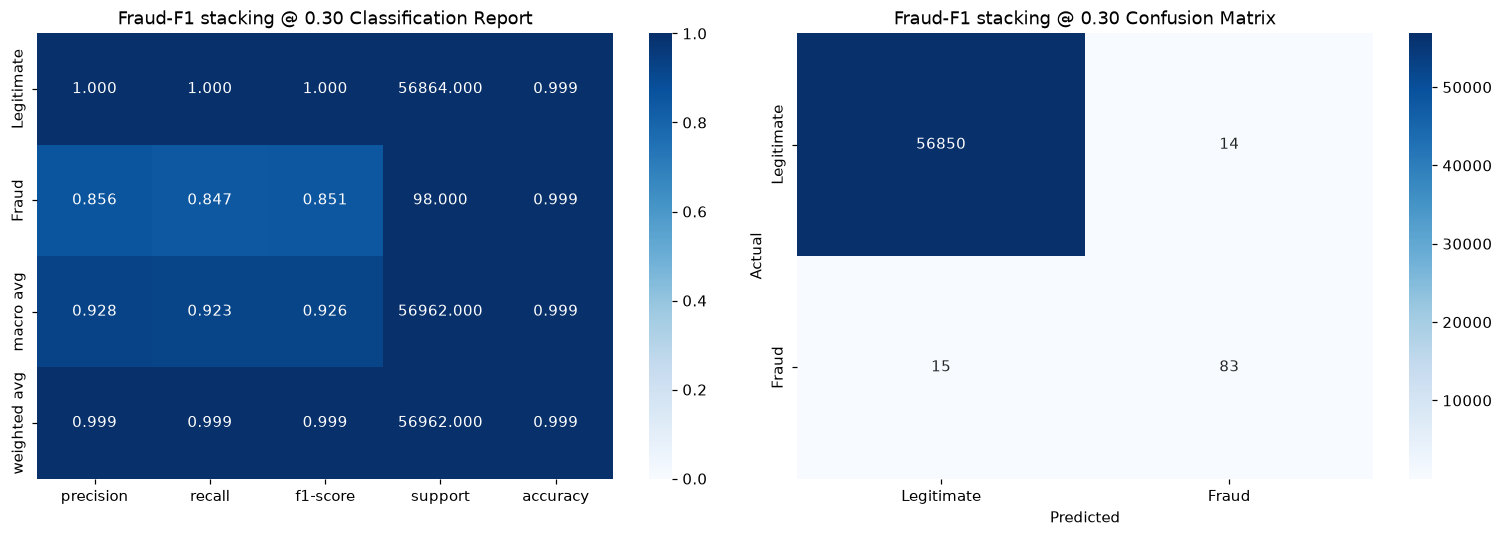

In [9]:
print(f"F1-oriented stacker @ {best_t:.2f} on TEST")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"], zero_division=0))
plot_report_and_cm(y_test, y_pred, f"Fraud-F1 stacking @ {best_t:.2f}")

compare = pd.DataFrame([
    {**old_exp03, "setting": "exp03 stacker, F2 @ 0.25"},
    {**old_f1_op, "setting": f"exp03 stacker, F1 @ {old_t_f1:.2f}"},
    {**new_test, "setting": f"exp04 new DT + meta, F1 @ {best_t:.2f}"},
])
print("Test comparison (fraud class)")
show_metrics(compare[METRIC_COLS])


## Missed frauds at the F1 cutoff

Black X marks are true frauds still predicted Legitimate. If they sit near `(0, 0)` on every pair, the base models also missed them — lowering the cutoff would mostly add false positives, not recover F1.


Missed frauds (FN) at t=0.30: 15  |  caught (TP): 83
       pred_dt  pred_knn  pred_rf  pred_stack
9179    0.9998    0.0000   0.2890      0.2497
17046   0.0000    0.0000   0.0000      0.0001
20992   0.0952    0.0000   0.0000      0.0014
24570   0.3368    0.0000   0.0097      0.0002
24869   0.0000    0.0000   0.0000      0.0001
28390   0.0952    0.0000   0.0100      0.0013
28867   0.9904    0.3333   0.3391      0.1761
31208   0.0000    0.0000   0.0000      0.0001
34124   0.0000    0.0000   0.0000      0.0001
39433   0.9836    0.0000   0.1291      0.0598
54191   0.8786    0.0000   0.1290      0.0281
54752   0.0952    0.0000   0.0000      0.0014
55247   0.0000    0.0000   0.0000      0.0001
56143   0.0176    0.0000   0.0000      0.0001
56287   0.0000    0.3333   0.2794      0.1050


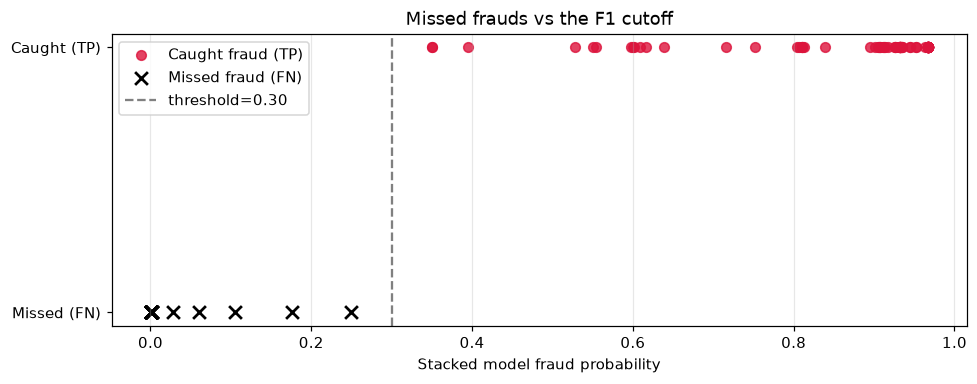

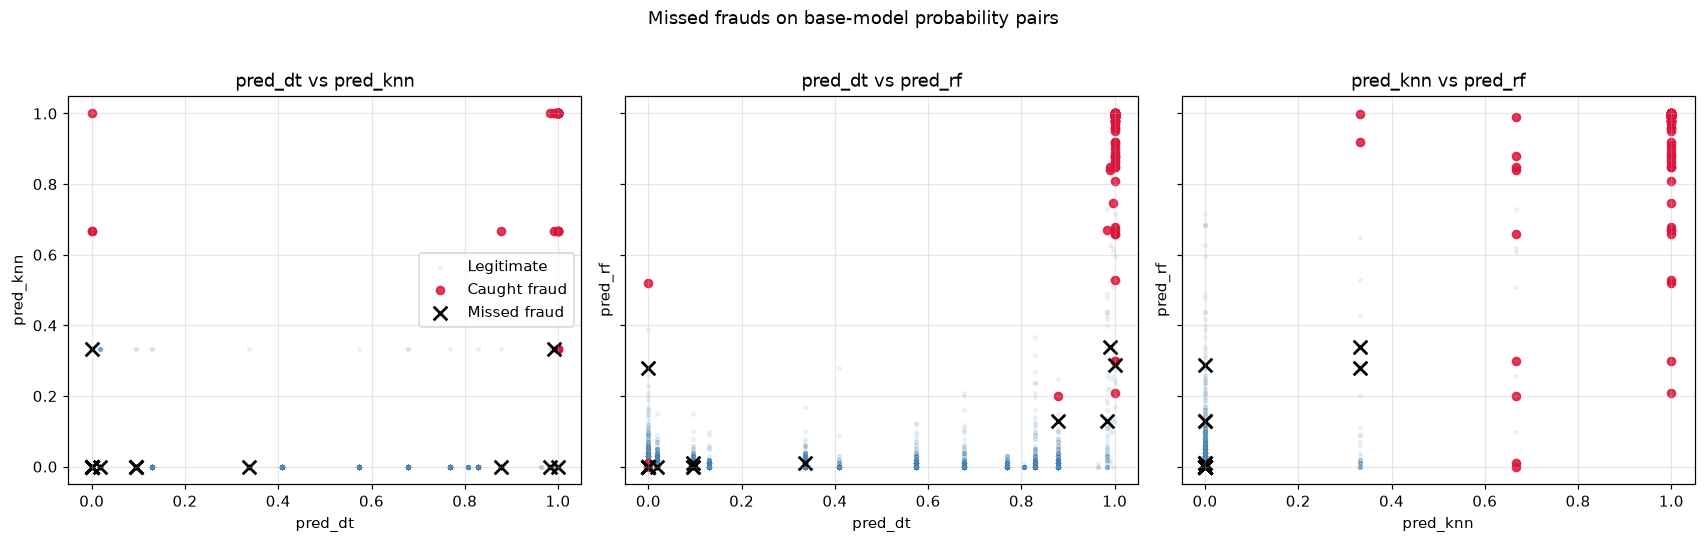

In [10]:
eval_df = stack_test[META_FEATURES].copy()
eval_df["pred_stack"] = proba_test
eval_df["y_true"] = y_test.to_numpy()
eval_df["y_pred"] = y_pred
missed = eval_df[(eval_df["y_true"] == 1) & (eval_df["y_pred"] == 0)]
caught = eval_df[(eval_df["y_true"] == 1) & (eval_df["y_pred"] == 1)]
legit = eval_df[eval_df["y_true"] == 0]

print(f"Missed frauds (FN) at t={best_t:.2f}: {len(missed)}  |  caught (TP): {len(caught)}")
print(missed[META_FEATURES + ["pred_stack"]].round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.scatter(caught["pred_stack"], np.ones(len(caught)), s=40, c="crimson", alpha=0.8, label="Caught fraud (TP)")
ax.scatter(missed["pred_stack"], np.zeros(len(missed)), s=70, c="black", marker="x", linewidths=1.8, label="Missed fraud (FN)")
ax.axvline(best_t, color="gray", linestyle="--", label=f"threshold={best_t:.2f}")
ax.set_xlabel("Stacked model fraud probability")
ax.set_yticks([0, 1], ["Missed (FN)", "Caught (TP)"])
ax.set_title("Missed frauds vs the F1 cutoff")
ax.legend(loc="upper left")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

pairs = list(combinations(META_FEATURES, 2))
fig, axes = plt.subplots(1, len(pairs), figsize=(5.2 * len(pairs), 4.8), sharex=True, sharey=True)
for ax, (x_col, y_col) in zip(axes, pairs):
    ax.scatter(legit[x_col], legit[y_col], s=6, alpha=0.08, c="steelblue", label="Legitimate")
    ax.scatter(caught[x_col], caught[y_col], s=28, alpha=0.85, c="crimson", label="Caught fraud")
    ax.scatter(missed[x_col], missed[y_col], s=80, c="black", marker="x", linewidths=1.8, label="Missed fraud")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}")
    ax.grid(True, alpha=0.3)
axes[0].legend()
fig.suptitle("Missed frauds on base-model probability pairs", y=1.02)
plt.tight_layout()
plt.show()


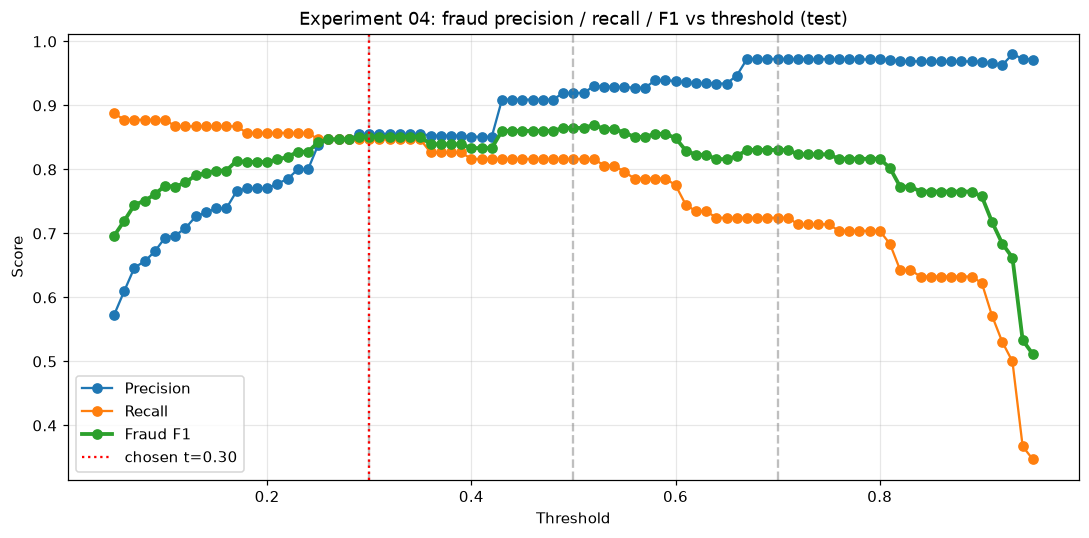

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_sweep["threshold"], test_sweep["precision"], marker="o", label="Precision")
ax.plot(test_sweep["threshold"], test_sweep["recall"], marker="o", label="Recall")
ax.plot(test_sweep["threshold"], test_sweep["f1"], marker="o", linewidth=2.5, label="Fraud F1")
for t in REQUIRED_THRESHOLDS:
    ax.axvline(t, color="gray", linestyle="--", alpha=0.5)
ax.axvline(best_t, color="red", linestyle=":", label=f"chosen t={best_t:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Experiment 04: fraud precision / recall / F1 vs threshold (test)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Takeaways

- Cutoffs are chosen on **train fraud F1**. That keeps precision from collapsing.
- Best honest result: **keep the experiment 03 stacker** and move the cutoff from F2 `0.25` to F1 **`0.40`**.
  - F2 @ 0.25: precision **0.83**, recall 0.87, F1 **0.85**, 17 FP
  - F1 @ 0.40: precision **0.90**, recall 0.83, F1 **0.86**, 9 FP
- Assignment threshold **0.5** on the same model is in the same neighborhood (precision 0.91, F1 0.87).
- Rebalancing the tree and retraining the meta-model did **not** beat that F1. The extra recall from `class_weight="balanced"` on the tree mostly becomes noise for a precision-sensitive stacker.
